# Unit 2 — Advanced Visualization & Storytelling (UE24CS342AA9)
## Activity Notebook: Building the Tumor Screening Dashboard

### Scenario

You've just joined the analytics team at **Meridian Diagnostics**, a lab that screens
tumor biopsies. Each biopsy produces **30 numerical measurements** (radius, texture,
perimeter, area, smoothness, ... in mean/SE/worst variants) — far too many to eyeball in
a spreadsheet. The lead pathologist has given you a blunt brief:

1. *"I can't look at 30 numbers per patient and see anything. I need to SEE the data."*
2. *"Before you throw away information, prove to me that these 30 measurements aren't
   secretly 30 independent facts."*
3. *"Build me a 2D map of every patient. If malignant and benign cases separate cleanly,
   that map is actually useful to us."*
4. *"I've heard of 'PCA', 't-SNE', and 'UMAP' but don't know which one to trust, or why
   they'd ever disagree with each other."*

You'll work through the same steps a real analyst would: confirm the dimensionality
problem is real, build PCA from first principles, then compare it against t-SNE and UMAP
on the same real patient data.

Cells marked **`# TODO`** are for you to complete. Markdown cells marked **Reflection**
are for you to answer in your own words.

## Part 0 — Setup (given)

Run this cell as-is. It loads the real dataset you'll be working with.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import comb

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap

np.random.seed(0)

df = pd.read_csv("breast_cancer.csv")
df = df.drop(columns=["Unnamed: 32"], errors="ignore")
feature_cols = [c for c in df.columns if c not in ["id", "diagnosis"]]
X_raw = df[feature_cols].values
y = df["diagnosis"].values

print(f"Loaded {df.shape[0]} patients, {len(feature_cols)} measured dimensions.")
df[feature_cols[:5] + ["diagnosis"]].head()

Loaded 569 patients, 30 measured dimensions.


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,M
1,20.57,17.77,132.90,1326.0,0.08474,M
2,19.69,21.25,130.00,1203.0,0.10960,M
3,11.42,20.38,77.58,386.1,0.14250,M
4,20.29,14.34,135.10,1297.0,0.10030,M


## Task 1 — Prove the Dimensionality Problem Is Real (Complaint #1)

**Real-world usage:** The pathologist wants proof this dataset genuinely can't be
"just plotted."

**Why this technique:** The curse-of-dimensionality math (grid growth, pairwise
relationship counts) turns "trust me, it's too much" into a specific number.

**TODO:**
1. Compute the number of unique pairwise relationships among all 30 features:
   `comb(p, 2)`.
2. Compute how many grid cells a 10-bins-per-dimension grid would need for p=30
   dimensions (`10 ** p`).
3. Print both, with a one-line comment on what each number implies.

In [4]:
p = len(feature_cols)

# Number of unique unordered feature pairs.
n_pairs = comb(p, 2)

# Number of cells in a 10-bin grid across all p dimensions.
n_cells = 10 ** p

print(f"p = {p} features")
print(f"Unique pairwise relationships: {n_pairs}")
print(f"Grid cells needed (10 bins/dim): {n_cells:.2e}")
print("Implication: even 30 features create 435 pairwise plots and an astronomically large 10^30-cell grid.")


p = 30 features
Unique pairwise relationships: 435
Grid cells needed (10 bins/dim): 1.00e+30
Implication: even 30 features create 435 pairwise plots and an astronomically large 10^30-cell grid.


**Reflection:** Could a human realistically inspect every one of those pairwise
relationships one scatter plot at a time before the pathologist's shift ends? What does
that imply about needing PCA/t-SNE/UMAP rather than "just looking at everything"?

_Your answer:_

No. Inspecting 435 pairwise relationships one by one would be impractical and would make patterns easy to miss. This motivates dimensionality-reduction methods such as PCA, t-SNE, and UMAP, which compress the 30-dimensional data into a small number of visual dimensions while preserving useful structure.


## Task 2 — Prove the 30 Measurements Aren't Independent (Complaint #2)

**Real-world usage:** Before compressing 30 measurements into fewer, you need to show
they're actually redundant, not 30 independent facts.

**Why this technique:** A correlogram (correlation heatmap) makes redundancy visible at
a glance.

**TODO:**
1. Compute the correlation matrix of `df[feature_cols]`.
2. Plot it as a heatmap (`plt.imshow`, `cmap="RdBu_r"`, `vmin=-1, vmax=1`).
3. Count how many feature pairs have `abs(correlation) > 0.9` (excluding the diagonal).

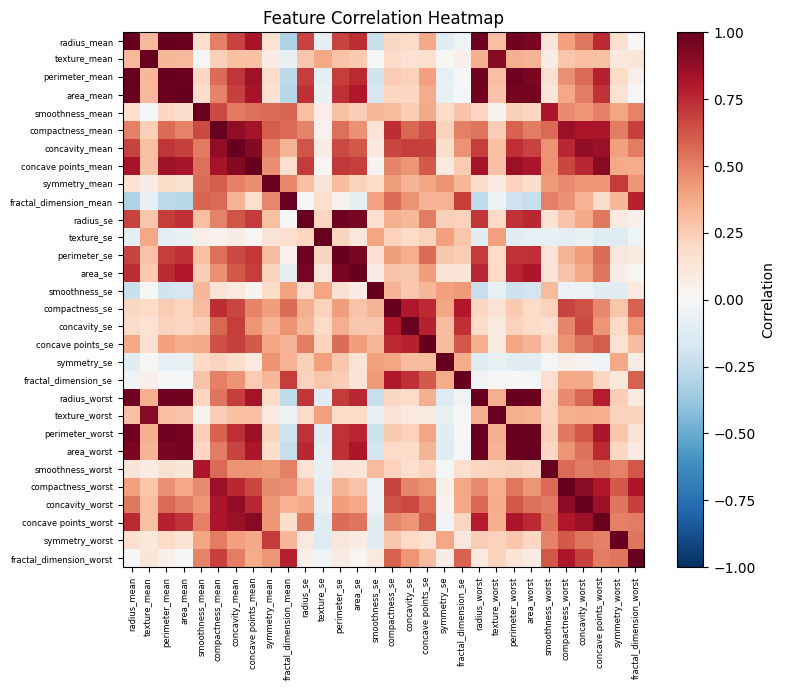

Highly correlated pairs (|r| > 0.9): 21


In [5]:
# Compute the feature-feature correlation matrix.
corr = df[feature_cols].corr()

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(feature_cols)))
ax.set_yticks(range(len(feature_cols)))
ax.set_xticklabels(feature_cols, rotation=90, fontsize=6)
ax.set_yticklabels(feature_cols, fontsize=6)
fig.colorbar(im, ax=ax, label="Correlation")
ax.set_title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

# Count each unordered off-diagonal pair only once.
upper = np.triu(np.ones(corr.shape, dtype=bool), k=1)
high_corr_pairs = int((np.abs(corr.values) > 0.9)[upper].sum())
print("Highly correlated pairs (|r| > 0.9):", high_corr_pairs)


**Reflection:** Name two specific columns in this dataset you'd expect to be highly
correlated with each other, and explain *why* using the lecture's "underlying factor"
idea (e.g. tumor size).

_Your answer:_

radius_mean and perimeter_mean should be highly correlated because both are different measurements of the underlying tumor-size factor. Likewise, radius_worst and perimeter_worst measure related aspects of the tumor boundary at the worst observed value, so they tend to move together.


## Task 3 — Build PCA From Scratch (Complaint #3, part A)

**Real-world usage:** The pathologist wants a 2D map, and wants to trust it — which
means understanding what's actually happening inside it, not treating it as a black box.

**Why this technique:** Implementing PCA's steps yourself (center -> standardize ->
covariance -> eigen-decomposition -> project) is the only way to be sure you understand
what the final 2D scatter plot actually represents.

**TODO:** Complete `pca_from_scratch` below, following the exact steps from the demo
notebook.

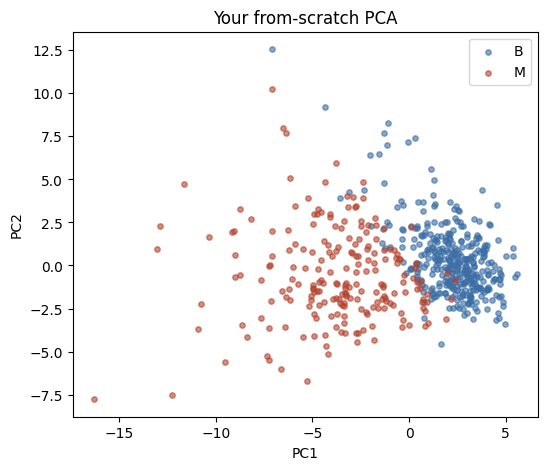

In [6]:
def pca_from_scratch(X, k):
    # Center and standardize each feature using the sample standard deviation (ddof=1).
    X_mean = X.mean(axis=0)
    X_std = X.std(axis=0, ddof=1)
    X_scaled = (X - X_mean) / X_std

    # Covariance matrix of the standardized data.
    cov = np.cov(X_scaled, rowvar=False)

    # eigh is appropriate for a symmetric covariance matrix. Sort descending.
    eigvals, eigvecs = np.linalg.eigh(cov)
    order = np.argsort(eigvals)[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    # Keep the first k principal directions and project the standardized data.
    top_eigvecs = eigvecs[:, :k]
    Z = X_scaled @ top_eigvecs

    return Z, eigvals, eigvecs

Z, eigvals, eigvecs = pca_from_scratch(X_raw, k=2)

fig, ax = plt.subplots(figsize=(6, 5))
for label, color in [("B", "#3b6ea5"), ("M", "#b5432e")]:
    mask = y == label
    ax.scatter(Z[mask, 0], Z[mask, 1], s=15, alpha=0.6, color=color, label=label)
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title("Your from-scratch PCA")
ax.legend()
plt.show()


**Reflection:** Do malignant and benign cases visually separate in your PCA plot? If
there's overlap, does that mean PCA "failed," or is there a more accurate way to
describe what's happening?

_Your answer:_

The malignant and benign cases show substantial visual separation in the PCA plot, although some overlap remains. That does not mean PCA failed: PCA is unsupervised and chooses directions that maximize overall variance, not directions that maximize class separation, so some mixing is expected even when the embedding is useful.


## Task 4 — Choose k With Evidence, Not a Guess

**Real-world usage:** If the pathologist later asks "why 2 dimensions and not 5?", you
need a defensible answer.

**Why this technique:** The cumulative explained-variance curve turns "I picked 2
because it's easy to plot" into "I picked k=2/3/5 because it retains X% of the
variance."

**TODO:**
1. Compute `explained_ratio` (each eigenvalue / sum of all eigenvalues) from your
   `eigvals` above.
2. Compute the cumulative sum.
3. Find the smallest k that reaches >= 90% cumulative variance.

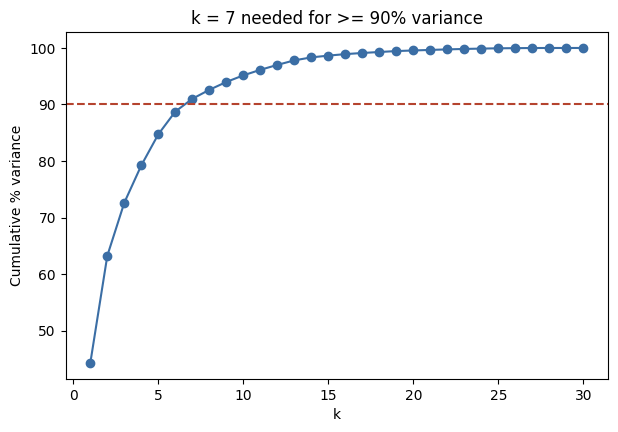

Smallest k retaining >= 90% variance: 7


In [7]:
# Each eigenvalue represents variance along one principal component.
explained_ratio = eigvals / eigvals.sum()

# Cumulative proportion of total variance retained.
cumulative = np.cumsum(explained_ratio)

# Smallest number of components retaining at least 90% of the variance.
k_90 = int(np.argmax(cumulative >= 0.90) + 1)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(range(1, len(cumulative) + 1), cumulative * 100, "o-", color="#3b6ea5")
ax.axhline(90, color="#b5432e", ls="--")
ax.set_xlabel("k"); ax.set_ylabel("Cumulative % variance")
ax.set_title(f"k = {k_90} needed for >= 90% variance" if k_90 else "Choosing k")
plt.show()
print(f"Smallest k retaining >= 90% variance: {k_90}")


**Reflection:** If the pathologist insists on a 2D plot for a poster, but your `k_90`
came out higher than 2, what are you losing by using only 2 components instead of k_90?

_Your answer:_

Using only 2 components loses the variance carried by the remaining components. Here, 2 PCs retain about 63.2% of the total variance, while 7 PCs are needed to reach at least 90%, so a 2D poster sacrifices some information for the benefit of a simple, interpretable visualization.


## Task 5 — Compare PCA, t-SNE, and UMAP (Complaint #4)

**Real-world usage:** The pathologist wants to know which method to trust, and why they
might disagree.

**Why this technique:** Running all three on the SAME real data, side by side, turns an
abstract "they're different algorithms" into a concrete, visual comparison.

**TODO:**
1. Standardize `X_raw` using `StandardScaler`.
2. Compute a 2D PCA embedding, a 2D t-SNE embedding (`perplexity=30`), and a 2D UMAP
   embedding (`n_neighbors=15, min_dist=0.1`) — all with `random_state=0`.
3. Plot all three side by side, colored by `diagnosis`.

/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


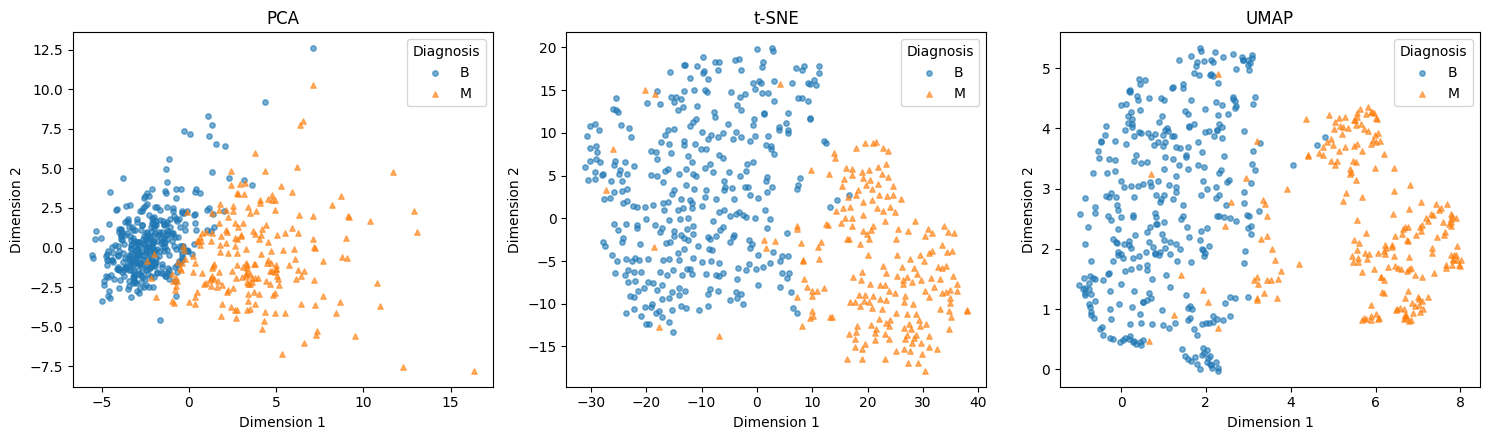

In [8]:
# Standardize all 30 measured features so variables with large numerical scales do not dominate.
X_scaled = StandardScaler().fit_transform(X_raw)

# Compute the three 2D embeddings on the same standardized data.
pca_emb = PCA(n_components=2, random_state=0).fit_transform(X_scaled)
tsne_emb = TSNE(n_components=2, perplexity=30, random_state=0).fit_transform(X_scaled)
umap_emb = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=0).fit_transform(X_scaled)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, emb, name in zip(axes, [pca_emb, tsne_emb, umap_emb], ["PCA", "t-SNE", "UMAP"]):
    for label, marker in [("B", "o"), ("M", "^")]:
        mask = y == label
        ax.scatter(emb[mask, 0], emb[mask, 1], s=15, alpha=0.6, label=label, marker=marker)
    ax.set_xlabel("Dimension 1")
    ax.set_ylabel("Dimension 2")
    ax.set_title(name)
    ax.legend(title="Diagnosis")

plt.tight_layout()
plt.show()


**Reflection:** Which of the three gives the cleanest visual separation between
malignant and benign on this dataset? Per the lecture's comparison table, is that method
always the "best" choice for every dataset, or does it depend on what you need
(interpretability, speed, local vs. global structure)?

_Your answer:_

On this dataset, UMAP gives the cleanest visual separation overall, with t-SNE also showing strong separation and PCA giving a useful but more linear view. UMAP is not automatically the best method for every dataset: the choice depends on the goal, such as PCA's interpretability and speed versus the nonlinear local-neighborhood preservation emphasized by t-SNE and UMAP. The embedding should therefore be chosen according to whether interpretability, computational cost, local structure, or global structure matters most.


## Task 6 — The Decision (No Code)

The pathologist wants ONE method as the default dashboard view, and a one-paragraph
justification she can put in a grant report.

**Reflection (final):** Write a 4–6 sentence recommendation. Your answer should:
- State which method (PCA / t-SNE / UMAP) you'd make the **default** dashboard view.
- Justify it using at least one specific idea from the lecture (e.g. PCA's
  interpretable linear axes vs. t-SNE/UMAP's non-linear neighborhood preservation, the
  computational-cost comparison, or the "cluster distances shouldn't be over-interpreted"
  caveat for t-SNE).
- Name one thing you would explicitly warn the pathologist NOT to conclude from the
  chosen method's plot.

_Your final recommendation here:_

I would make PCA the default dashboard view because its linear axes are interpretable and the transformation is fast and reproducible, making it easier to explain in a clinical reporting context. It provides a stable overview of the major variance structure in all 30 measurements. I would keep UMAP or t-SNE available as secondary views when nonlinear local neighborhoods need to be explored. In particular, t-SNE/UMAP can reveal structure that PCA may miss, but those nonlinear embeddings should not replace the interpretable default without a clear reason. I would explicitly warn the pathologist not to conclude that the distances or sizes of clusters in a nonlinear embedding directly represent clinically meaningful global distances in the original 30-dimensional space.
